# Improved LSTM focused model

Train: (2319, 22) Val: (580, 22)
RF best params: {'n_estimators': 800, 'min_samples_split': 10, 'max_depth': 20}
⚠️ Old XGBoost version detected — training without early stopping.
LSTM seq shapes -> train: (2259, 60, 22) val: (580, 60, 22)

Epoch 1/100
71/71 - 5s - 73ms/step - loss: 0.0107 - mae: 0.0632 - val_loss: 0.0044 - val_mae: 0.0533 - learning_rate: 5.0000e-04
Epoch 2/100
71/71 - 3s - 42ms/step - loss: 0.0024 - mae: 0.0320 - val_loss: 0.0039 - val_mae: 0.0500 - learning_rate: 5.0000e-04
Epoch 3/100
71/71 - 3s - 42ms/step - loss: 0.0022 - mae: 0.0310 - val_loss: 0.0035 - val_mae: 0.0448 - learning_rate: 5.0000e-04
Epoch 4/100
71/71 - 3s - 43ms/step - loss: 0.0019 - mae: 0.0283 - val_loss: 0.0035 - val_mae: 0.0449 - learning_rate: 5.0000e-04
Epoch 5/100
71/71 - 3s - 42ms/step - loss: 0.0018 - mae: 0.0276 - val_loss: 0.0032 - val_mae: 0.0445 - learning_rate: 5.0000e-04
Epoch 6/100
71/71 - 3s - 42ms/step - loss: 0.0017 - mae: 0.0268 - val_loss: 0.0041 - val_mae: 0.0468 - learning_ra

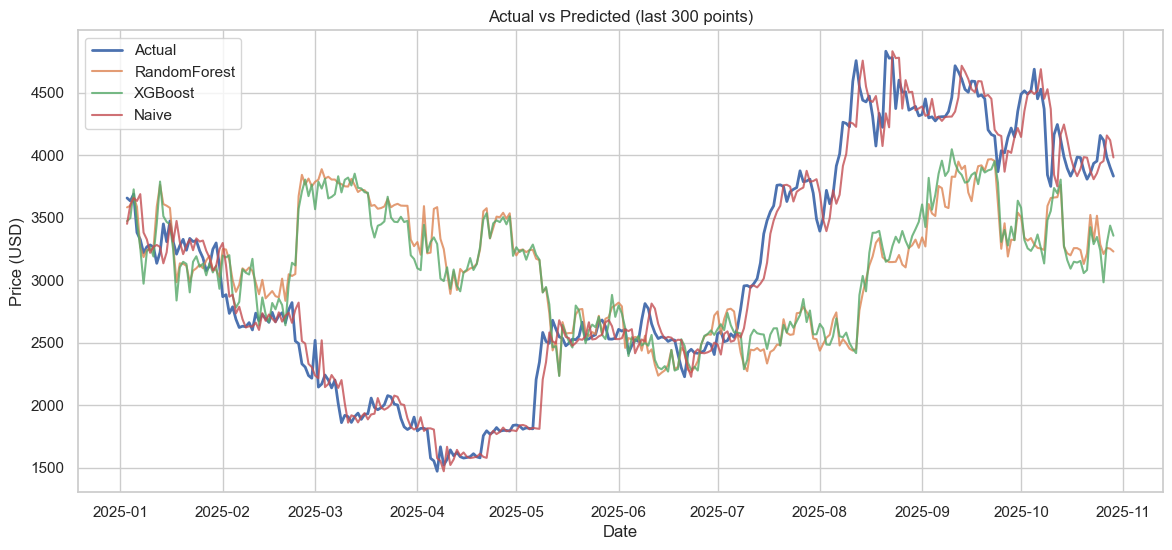

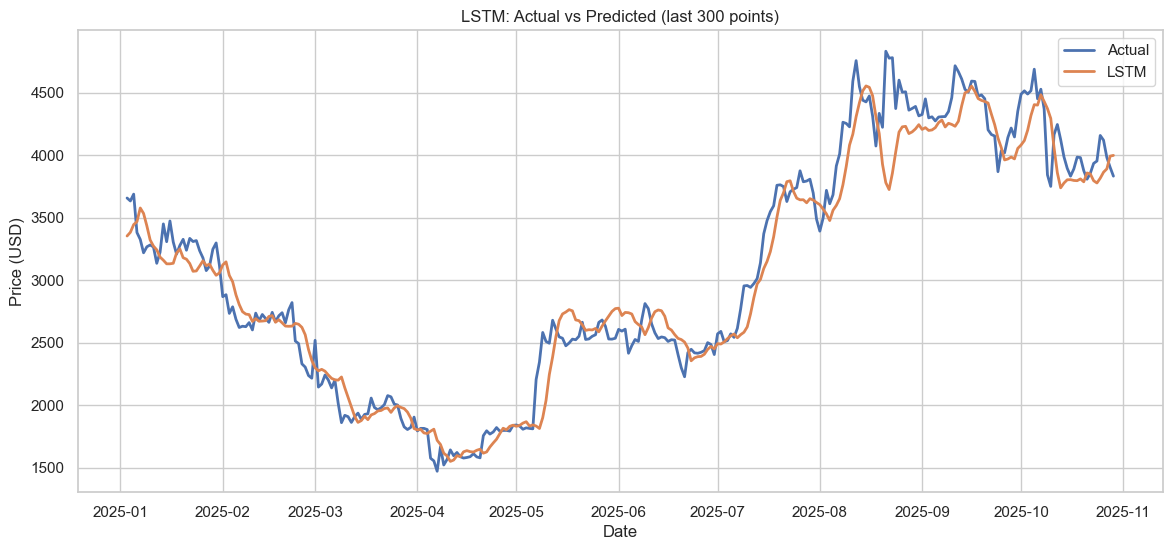

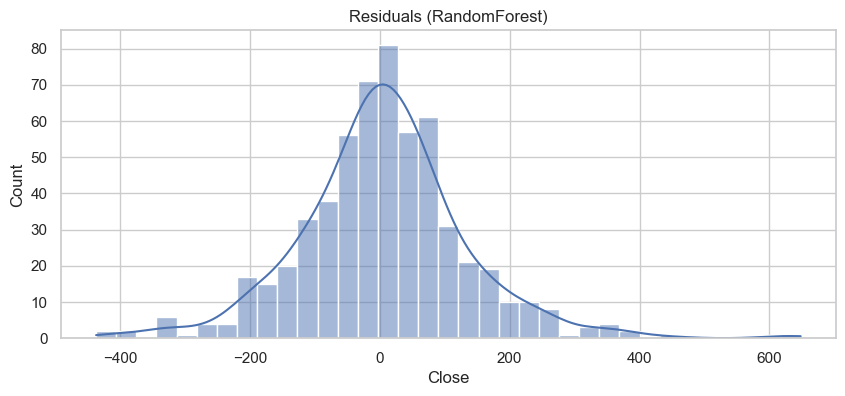

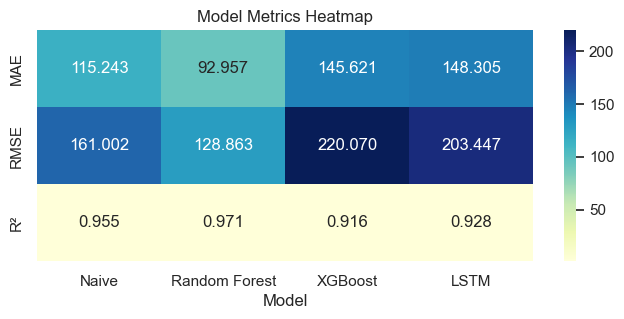

In [11]:
# ======================================================
# IMPROVED END-TO-END PIPELINE (RF / XGB / LSTM / PLOTS)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

sns.set(style="whitegrid")

# ------------------------------------------------------
# 1) Load and prepare data
# ------------------------------------------------------
df = pd.read_csv("../data/Crypto_historical_data.csv", parse_dates=["Date"], index_col="Date")
coin = "ETH-USD"
coin_df = df[df['ticker'] == coin].sort_index()
coin_df = coin_df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

# ------------------------------------------------------
# 2) Feature engineering
# ------------------------------------------------------
def create_features(df, lags=[1, 2, 3, 5, 10], windows=[3, 7, 14]):
    X = pd.DataFrame(index=df.index)
    X['close'] = df['Close']
    X['log_ret'] = np.log(df['Close']).diff()
    X['range'] = df['High'] - df['Low']
    X['dayofweek'] = df.index.dayofweek
    X['month'] = df.index.month
    X['day_sin'] = np.sin(2 * np.pi * X['dayofweek'] / 7)
    X['day_cos'] = np.cos(2 * np.pi * X['dayofweek'] / 7)
    for l in lags:
        X[f'lag_{l}'] = df['Close'].shift(l)
    for w in windows:
        X[f'rolling_mean_{w}'] = df['Close'].rolling(w).mean()
        X[f'rolling_std_{w}'] = df['Close'].rolling(w).std()
        X[f'rolling_max_{w}'] = df['Close'].rolling(w).max()
    X['vol_mean_7'] = df['Volume'].rolling(7).mean()
    return X.dropna()

X_all = create_features(coin_df)
y_all = coin_df['Close'].loc[X_all.index].shift(-1).iloc[:-1]
X_all = X_all.iloc[:-1]

# ------------------------------------------------------
# 3) Train/validation split
# ------------------------------------------------------
n = len(X_all)
train_end = int(n * 0.8)
X_train, X_val = X_all.iloc[:train_end], X_all.iloc[train_end:]
y_train, y_val = y_all.iloc[:train_end], y_all.iloc[train_end:]
print("Train:", X_train.shape, "Val:", X_val.shape)

# ------------------------------------------------------
# 4) Random Forest
# ------------------------------------------------------
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
tscv = TimeSeriesSplit(n_splits=3)
param_dist = {
    'n_estimators': [200, 400, 800],
    'max_depth': [6, 12, 20, None],
    'min_samples_split': [2, 5, 10]
}
rscv = RandomizedSearchCV(
    rf, param_dist, n_iter=8, cv=tscv,
    scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42
)
rscv.fit(X_train, y_train_log)
rf_best = rscv.best_estimator_
print("RF best params:", rscv.best_params_)

y_pred_rf = np.expm1(rf_best.predict(X_val))

# ------------------------------------------------------
# 5) XGBoost
# ------------------------------------------------------
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
                             tree_method='hist', n_jobs=-1, random_state=42)

val_hold = max(10, int(len(X_train)*0.1))
X_train_xgb, y_train_xgb = X_train.iloc[:-val_hold], np.log1p(y_train.iloc[:-val_hold])
X_eval_xgb, y_eval_xgb = X_train.iloc[-val_hold:], np.log1p(y_train.iloc[-val_hold:])

try:
    xgb_model.fit(X_train_xgb, y_train_xgb,
                  eval_set=[(X_eval_xgb, y_eval_xgb)],
                  early_stopping_rounds=50, verbose=False)
except TypeError:
    print("⚠️ Old XGBoost version detected — training without early stopping.")
    xgb_model.fit(X_train_xgb, y_train_xgb, verbose=False)

y_pred_xgb = np.expm1(xgb_model.predict(X_val))

# ------------------------------------------------------
# 6) LSTM (sequence model)
# ------------------------------------------------------
scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))

def make_sequences(X_arr, y_arr, idx, seq_len=60):
    Xs, ys, idxs = [], [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i:i+seq_len])
        ys.append(y_arr[i+seq_len])
        idxs.append(idx[i+seq_len])
    return np.array(Xs), np.array(ys), np.array(idxs)

seq_len = 60
X_all_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_all_scaled = np.vstack([y_train_scaled, y_val_scaled])
idx_all = np.concatenate([X_train.index, X_val.index])

X_seq, y_seq, idx_seq = make_sequences(X_all_scaled, y_all_scaled, idx_all, seq_len)
train_mask = np.isin(idx_seq, X_train.index)
val_mask = np.isin(idx_seq, X_val.index)

X_tr_seq, y_tr_seq = X_seq[train_mask], y_seq[train_mask]
X_va_seq, y_va_seq, idx_va = X_seq[val_mask], y_seq[val_mask], idx_seq[val_mask]

print("LSTM seq shapes -> train:", X_tr_seq.shape, "val:", X_va_seq.shape)

tf.keras.backend.clear_session()
lstm_model = models.Sequential([
    layers.Input(shape=(seq_len, X_tr_seq.shape[2])),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.Dense(1)
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
                   loss='mse', metrics=['mae'])

history = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_va_seq, y_va_seq),
    epochs=100, batch_size=32,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6)
    ],
    verbose=2
)

# Predictions
y_pred_lstm_scaled = lstm_model.predict(X_va_seq)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_va_actual = scaler_y.inverse_transform(y_va_seq).flatten()
y_pred_lstm_series = pd.Series(y_pred_lstm, index=pd.to_datetime(idx_va))
y_va_series = pd.Series(y_va_actual, index=pd.to_datetime(idx_va))

# ------------------------------------------------------
# 7) Naive predictor
# ------------------------------------------------------
y_pred_naive_series = X_val['lag_1']

# ------------------------------------------------------
# 8) Metrics
# ------------------------------------------------------
def metrics_for(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Align correctly for each model
mae_naive, rmse_naive, r2_naive = metrics_for(y_val, y_pred_naive_series)
mae_rf, rmse_rf, r2_rf = metrics_for(y_val, y_pred_rf)
mae_xgb, rmse_xgb, r2_xgb = metrics_for(y_val, y_pred_xgb)
# For LSTM, directly compare its actuals & preds
mae_lstm, rmse_lstm, r2_lstm = metrics_for(y_va_series, y_pred_lstm_series)

results = pd.DataFrame({
    'Model': ['Naive', 'Random Forest', 'XGBoost', 'LSTM'],
    'MAE': [mae_naive, mae_rf, mae_xgb, mae_lstm],
    'RMSE': [rmse_naive, rmse_rf, rmse_xgb, rmse_lstm],
    'R²': [r2_naive, r2_rf, r2_xgb, r2_lstm]
})
print("\nModel Comparison:\n", results.round(4))

# ------------------------------------------------------
# 9) Visualization (Seaborn)
# ------------------------------------------------------
N = 300
viz_idx = y_val.index[-N:]
plt.figure(figsize=(14,6))
sns.lineplot(x=viz_idx, y=y_val.loc[viz_idx], label="Actual", linewidth=2)
sns.lineplot(x=viz_idx, y=y_pred_rf[:N], label="RandomForest", alpha=0.8)
sns.lineplot(x=viz_idx, y=y_pred_xgb[:N], label="XGBoost", alpha=0.8)
sns.lineplot(x=viz_idx, y=y_pred_naive_series.loc[viz_idx], label="Naive", alpha=0.8)
plt.title("Actual vs Predicted (last {} points)".format(N))
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend(); plt.show()

plt.figure(figsize=(14,6))
sns.lineplot(x=y_va_series.index[-N:], y=y_va_series[-N:], label="Actual", linewidth=2)
sns.lineplot(x=y_va_series.index[-N:], y=y_pred_lstm_series[-N:], label="LSTM", linewidth=2)
plt.title("LSTM: Actual vs Predicted (last {} points)".format(N))
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend(); plt.show()

plt.figure(figsize=(10,4))
sns.histplot((y_val - y_pred_rf), kde=True)
plt.title("Residuals (RandomForest)")
plt.show()

plt.figure(figsize=(8,3))
sns.heatmap(results.set_index('Model').T, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Model Metrics Heatmap")
plt.show()
